#### Test plotting functions using the H2H2 data.

/home/tqz/Documents/University/Master Thesis/scatteringkernels/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


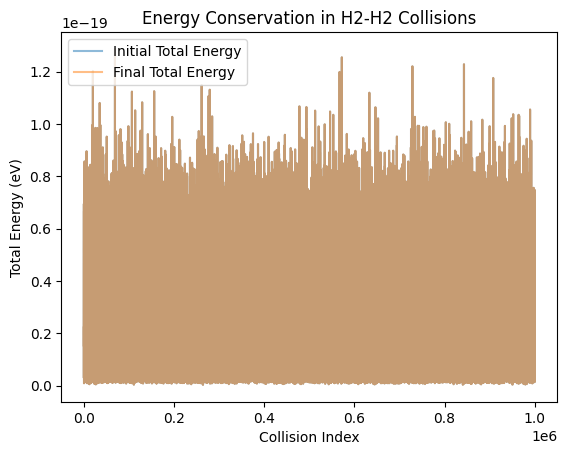

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Check energy conservation
# datafile = "data/H2H2_collisions.csv"
# mdn_path = "results/models/mdn_H2H2.pth"
datafile = "data/filtered/O2O2_collisions.npy"
mdn_path = "results/models/mdn_O2O2.pth"
if ".npy" in datafile:
    data = np.load(datafile)
    data = pd.DataFrame(data, columns=["Etr", "Er1", "Er2", "Etrp", "Er1p", "Er2p"])
elif ".csv" in datafile:
    data = pd.read_csv(datafile, skiprows=1)
else:
    raise ValueError("Unsupported file format. Please provide a .csv or .npy file.")

Etot_init = data.iloc[:,0] + data.iloc[:,1] + data.iloc[:,2]
Etot_final = data.iloc[:,3] + data.iloc[:,4] + data.iloc[:,5]
plt.plot(Etot_init, label='Initial Total Energy', alpha=0.5)
plt.plot(Etot_final, label='Final Total Energy', alpha=0.5)
plt.xlabel('Collision Index')
plt.ylabel('Total Energy (eV)')
plt.title('Energy Conservation in H2-H2 Collisions')
plt.legend()
plt.show()


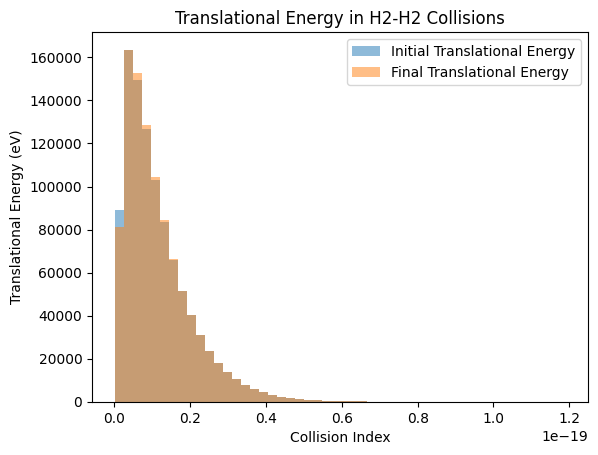

In [2]:
Etr_init = data.iloc[:,0]
Etr_final = data.iloc[:,3]
plt.hist(Etr_init, bins=50, alpha=0.5, label='Initial Translational Energy')
plt.hist(Etr_final, bins=50, alpha=0.5, label='Final Translational Energy')
plt.xlabel('Collision Index')
plt.ylabel('Translational Energy (eV)')
plt.title('Translational Energy in H2-H2 Collisions')
plt.legend()
plt.show()

This indicates the energy distribution nudges toward equilibrium over many collisions.

In [3]:
import torch
from utils.helpers import load_dataset
from machinelearning.mdn import MixtureDensityNetwork
from machinelearning.gmm import GaussianMixtureModel
from config.experiment_config import ExperimentConfig
config = ExperimentConfig()

data = load_dataset(datafile, rows=config.num_samples)

# Sample MDN
mdn = MixtureDensityNetwork(input_dim=config.input_dim, output_dim=config.output_dim, num_mixtures=config.num_mixtures, hidden_dim=config.hidden_dim, randomseed=config.random_seed) 
mdn.load_model(mdn_path)
torch.manual_seed(config.random_seed+1)
mdn_samples = mdn.sample(x=data[0])

# Sample GMM
gmm = GaussianMixtureModel(n_components=config.gmm_n_components, covariance_type=config.gmm_covariance_type)
gmm.fit(data[1])
gmm_samples = gmm.sample(num_samples=config.num_samples)

datasets = {
    "inputs": data[0][:,1:], # Use only the energy fractions for plotting not the total energy
    "CTC": data[1],
    "MDN": mdn_samples,
    # "GMM": gmm_samples
}

Dataset contains 30000 rows


CTC, eta_tr: average crossover with diagonal at x = 0.6758
MDN, eta_tr: average crossover with diagonal at x = 0.6760
CTC, eta_rot_A: average crossover with diagonal at x = 0.4967
MDN, eta_rot_A: average crossover with diagonal at x = 0.4651


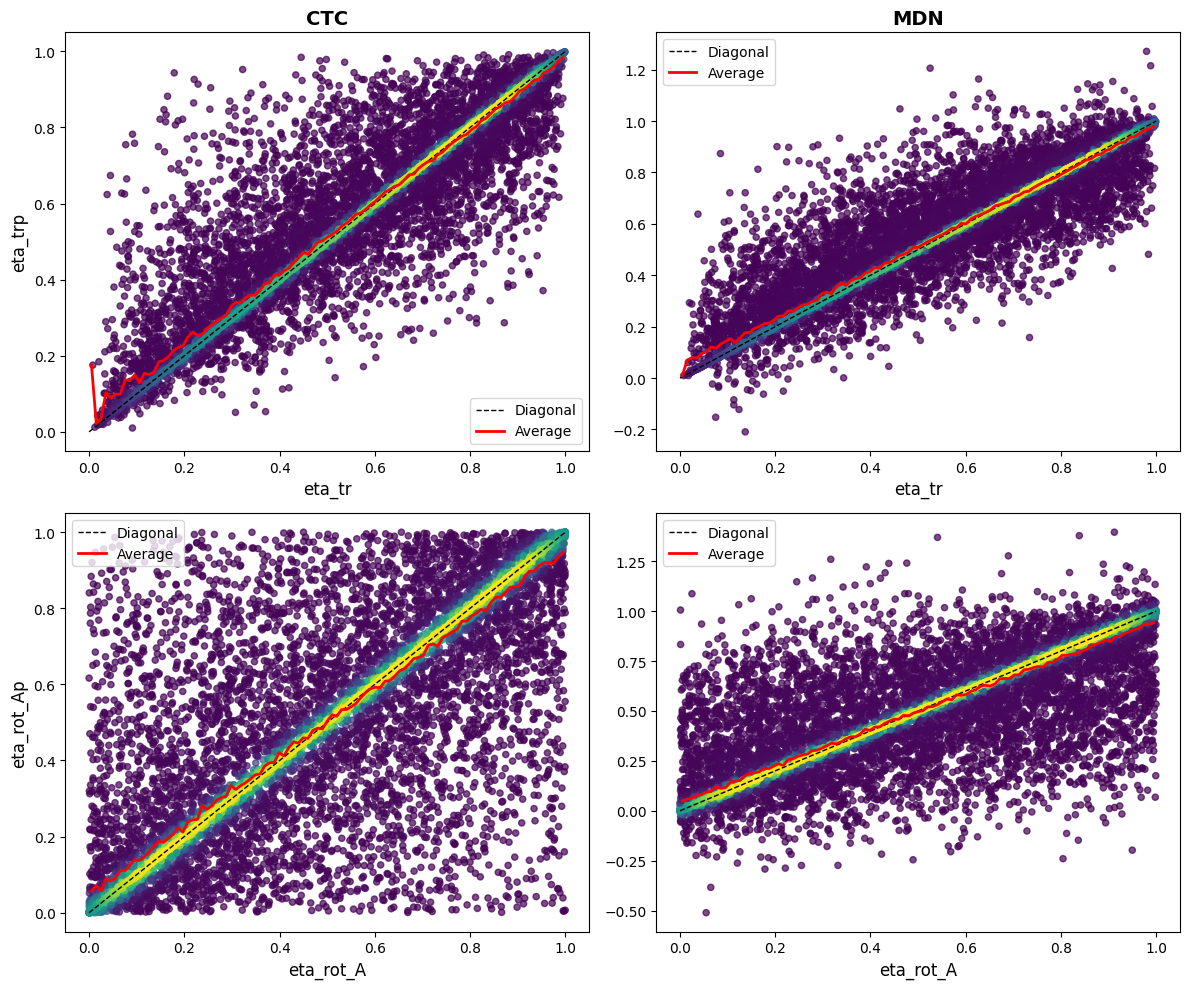

In [ ]:
from visualization.plot import plot_density_scatter
from config.plotting_config import PlottingConfig
plotting_config = PlottingConfig()

# Create scatterplot
figsize_x = plotting_config.figsize[0] * 2
figsize_y = plotting_config.figsize[1] * 2
fig, ax = plt.subplots(2, 2, figsize=(figsize_x, figsize_y))
plot_density_scatter(ax, datasets=datasets)

datasetnames = list(datasets.keys())
datasetnames.remove("inputs")

eta_labels = ["eta_tr", "eta_rot_A"]
n = 100
for i in range(2):
    x = datasets["inputs"][:, i]
    for j, dataset_name in enumerate(datasetnames):
        y = datasets[dataset_name][:, i]

        # Plot diagonal
        ax[i, j].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Diagonal')

        # Bin the x-axis and compute means
        bins = np.linspace(0, 1, n)
        bin_indices = np.digitize(x, bins)
        bin_means = np.array([y[bin_indices == k].mean() for k in range(1, len(bins))])
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # Plot a line connecting binned averages
        ax[i, j].plot(bin_centers, bin_means, color='red', label='Average', linewidth=2)
        ax[i, j].legend()

        # Find crossing with diagonal (bin_means - bin_centers changes sign)
        x_crossings = []
        diff = bin_means - bin_centers
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        for idx in sign_changes:
            x0, x1 = bin_centers[idx], bin_centers[idx + 1]
            d0, d1 = diff[idx], diff[idx + 1]
            x_cross = x0 - d0 * (x1 - x0) / (d1 - d0)
            x_crossings.append(x_cross)

        if x_crossings:
            avg_x_cross = float(np.mean(x_crossings))
            print(f"{dataset_name}, {eta_labels[i]}: average crossover with diagonal at x = {avg_x_cross:.4f}")
        else:
            print(f"{dataset_name}, {eta_labels[i]}: no crossover with diagonal detected")

        ax[i, j].set_xlim(0, 1)
        ax[i, j].set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [5]:
from analysis.kl_divergence import kl_divergence

kl_ctc_mdn_tr  = kl_divergence(datasets["CTC"][:, 0], datasets["MDN"][:, 0])
kl_ctc_mdn_rot = kl_divergence(datasets["CTC"][:, 1], datasets["MDN"][:, 1])

print(f"KL Divergence (eta_tr):    {kl_ctc_mdn_tr:.4f}")
print(f"KL Divergence (eta_rot_A): {kl_ctc_mdn_rot:.4f}")

KL Divergence (eta_tr):    0.0015
KL Divergence (eta_rot_A): 0.0059
